''''''''' 
- **단층 퍼셉트론**
    - 단층 퍼셉트론의 한계
- **다층 퍼셉트론**
- **딥러닝 모델의 학습 방법**
    - 순전파와 역전파, 연쇄 법칙
    - 손실 함수의 정의와 종류
    - 활성화 함수의 정의와 종류
    - 옵티마이저의 정의와 종류  

'''''''''

# **인공신경망과 퍼셉트론**
## 인공신경망이란?
### [인공신경망]
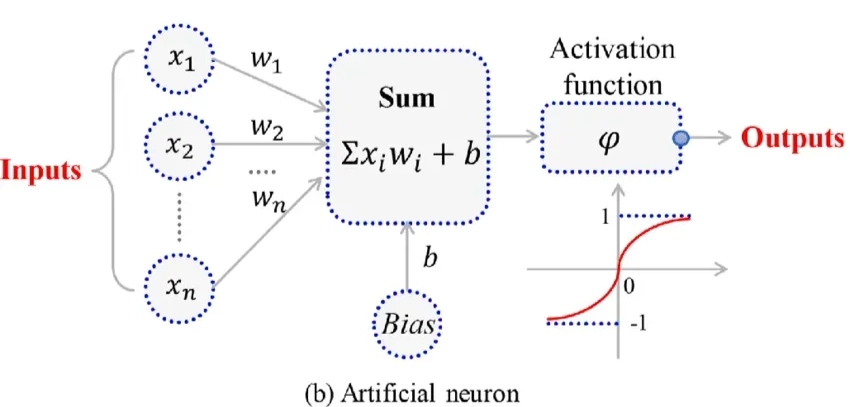  
- 개념: 인간의 뇌의 신경망을 모방한 모델
- x(input)*w + b -> 활성화 함수 적용(임계값 기준) -> output

### [퍼셉트론]
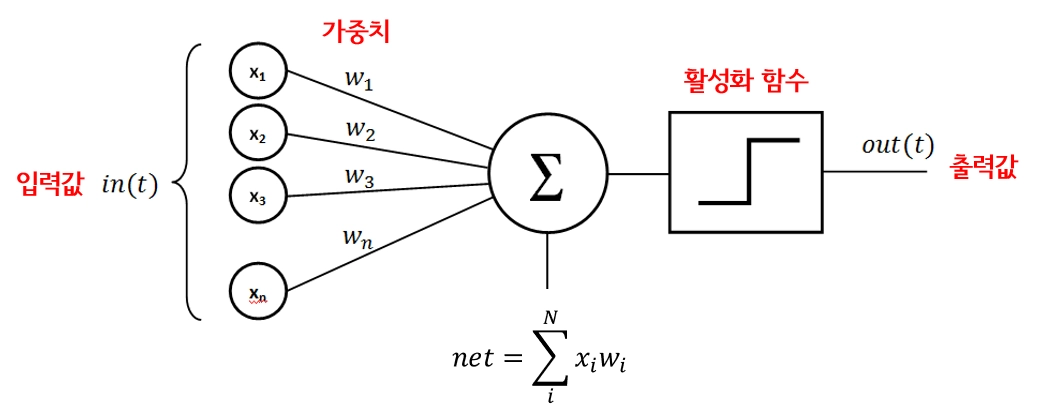  
- 개념: 초기 형태의 인공신경망으로, 신경망(딥러닝)의 기원이 되는 선형 이진 분류기
- x_i(input) * w_i의 합이 임계값을 넘으면 1, 넘지 않으면 0 출력 (i = 1~n)   <- Step 함수
- 가중치(w): 입력값이 출력값에 주는 영향력(중요도)
- 활성화 함수
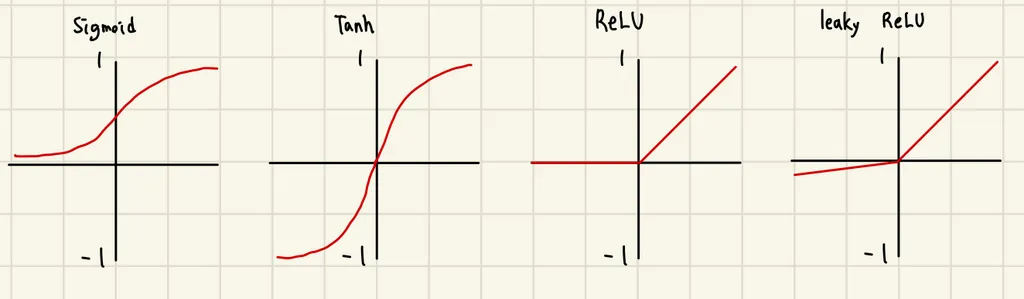  
    - 계단함수: 신호가 임계값을 넘으면 1, 넘지 못하면 0을 출력
    - 시그모이드
    - Tanh: -1 ~ 1 사이의 값 출력
    - ReLU: 음수 부분을 0으로 만들어, 양수값을 주로 다룰 때는 계산 속도상의 이점 존재
- 임계값(𝜃): 가중합 >= 임계값 -> y = 1, 가중합 < 임계값 -> y = 0
    
$$\begin{aligned}&\text{if } \sum_{i}^{n} w_i x_i \ge \theta \rightarrow y=1 \\&\text{if } \sum_{i}^{n} w_i x_i < \theta \rightarrow y=0\end{aligned}$$
- 편향(b): 위의 식에서 임계값을 좌변으로 넘긴 것
$$\begin{aligned}&\text{if } \sum_{i}^{n} W_i x_i + b \ge 0\rightarrow y=1 \\&\text{if } \sum_{i}^{n} W_i x_i + b < 0\rightarrow y=0\end{aligned}$$

## **단층 퍼셉트론과 그 한계**
### [단층 퍼셉트론]
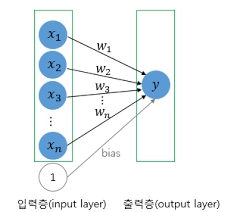
- 개념: 입력층과 출력층으로만 이루어진 퍼셉트론
- 논리 게이트의 구현
    - AND: 입력값이 모두 1일 때만 출력값이 1  
    ex) $[w1, w2, b] = [0.5, 0.5, -0.7], [0.5, 0.5, -0.8], [1.0, 1.0, -1.0]$
    - OR: 입력값이 모두 0일 때만 출력값이 0  
    ex) $[w1, w2, b] = [0.6, 0.6, -0.5]$
    - NAND: NOT AND -> 입력값이 모두 1일 때만 출력값이 0  
    ex) $[w1, w2, b] = [-0.5, -0.5, 0.7]$
    - XOR: 입력값 두 개가 서로 다르면 1, 같으면 0
- **단층 퍼셉트론의 한계**: **XOR 게이트 구현 불가**
    - WHY?  
    퍼셉트론은 입력값과 가중치의 선형 결합 -> 단층 퍼셉트론은 직선 하나로 두 영역을 나눌 수 있는 선형 분류 문제만 구현 가능 -> 하지만 XOR은 직선 하나로 나눌 수 없다

## **다층 퍼셉트론(MLP)**
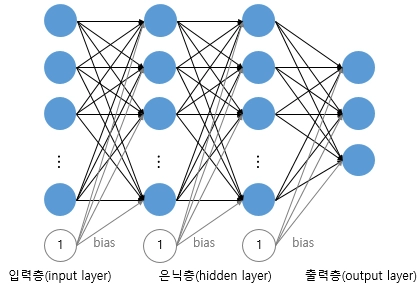  
- XOR 게이트 구현 가능
    - HOW?  
    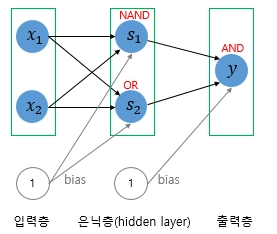  
    퍼셉트론의 층을 더 쌓아서 AND, NAND, OR를 결합하자. 이때 추가되는 층을 **은닉층**이라고 한다.
- 딥러닝의 시초 모델은 두 개 이상의 은닉층을 갖는 MLP = 심층 신경망(DNN)
- 딥러닝: 심층 신경망을 학습하여 스스로 가중치를 찾도록 함

# **딥러닝 모델의 학습**
## 순전파와 역전파
### [학습 알고리즘의 기본 구조]
1. **순전파** -> 입력값으로부터 **예측** (입력층->정답 방향)
2. 오차(**손실**) 계산 -> **예측 정확도 측정**
3. **역전파** -> 출력층에서 다시 입력층 방향으로 오차 전달 (정답->입력층 방향). **각 가중치의 손실에 대한 기여도 측정**
4. **가중치 업데이트**
5. 1~4 반복
### [연쇄 법칙]
- 입력값이 출력값에 미친 영향력을 계산하기 위해 각 층이 다음 층에 미친 영향을 순서대로 곱해나가는 것  
ex) A-B-C 층이 있을 때 A가 C에 미치는 영향 = (B가 C에 미치는 영향) x (A가 B에 미치는 영향)
$$\frac{∂C}{∂A}=\frac{∂C}{∂B}×\frac{∂B}{∂A}$$
- 역전파 과정에서 각 가중치가 최종 손실에 얼마나 기여했는지 계산할 때 사용 -> 오차 감소
### [기울기 소실 문제]
- 각 단계마다 기울기가 1보다 작아서 계속 곱했더니 결국 기울기가 0이 되는 문제
- 앞쪽의 가중치가 거의 업데이트 X(영향력 X) -> 학습이 제대로 되지 않는다

## 손실 함수
- 개념: 실제값과 예측값의 차이를 계산하는 데에 사용되는 함수
- 종류
    - 평균제곱오차(MSE): **회귀**에서 주로 사용(예측값이 연속적, 오차를 직접 측정)
    $$\frac{1}{N}\sum(y-\hat{y})^2 \ \ \ \ \ \ (y: 실제값,\ \ \hat{y} : 예측값)$$
    - 이진 크로스 엔트로피(BCE): **이진분류문제**(로지스틱 회귀)에서 주로 사용. **얼마나 확신을 가지고 예측했는지 반영**->낮은 확률로 예측해서 맞추거나 높은 확률로 예측해서 틀리는 경우 손실이 더 크다.    
    $$L= -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$$
    $$y : 실제값(0,1)이진값,\ \ \hat{y} : 예측값(확률)$$

    | 실제 정답 (y) | 예측 확률 (y_hat) | Loss 식 | Loss 변화 | 의미      |
    | --------- | ------------- | --------------- | ------- | ------- |
    | 1         | 1에 가까움        | -log(y_hat)     | 0에 가까움  | 정답 잘 맞힘 |
    | 1         | 0에 가까움        | -log(y_hat)     | 매우 커짐   | 틀렸고 확신함 |
    | 0         | 0에 가까움        | -log(1 - y_hat) | 0에 가까움  | 정답 잘 맞힘 |
    | 0         | 1에 가까움        | -log(1 - y_hat) | 매우 커짐   | 틀렸고 확신함 |

    - 크로스 엔트로피 오차(CEE): **다중 클래스 분류 문제**에서 예측 확률과 실제 클래스의 일치 정도를 평가하는 데 적합. **두 확률 분포(정답/예측)의 유사도 측정**에 유용하다.
    $$-\sum y \log \hat{y}$$
    $$y : 원-핫 인코딩\ 값 (1,0),\ \ \hat{y} : 예측값(확률)$$
    *확률값(0~1)을 로그에 적용하면 음수이므로 식 앞에 -를 붙여서 양수로 바꿔준다.

## 활성화 함수
- 개념: 각 층의 출력값에 비선형성을 추가해서 신경망이 복잡한 패턴(ex: XOR)도 학습할 수 있게 해주는 함수  

|  | **단층 퍼셉트론** | **다층 퍼셉트론** |
| --- | --- | --- |
| **활성화 함수** | 계단 함수 | Sigmoid, ReLU 등 |
| **출력값** | 0 또는 1 (이진 출력) | 연속적인 값 (확률 또는 실수) |
| **특징** | 선형 문제만 풀 수 있음 | 복잡한 비선형 문제도 학습 가능 |

- 종류
    - 계단함수 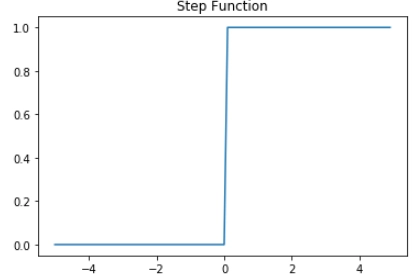  
        -  $h(x) = \begin{cases} 1 & (x \geq 0) \\ 0 & (x < 0) \end{cases}$ -> 맞다/틀리다
        - 임계값은 뉴런이 얼마나 쉽게 활성화되는지 조절
    - 시그모이드 함수 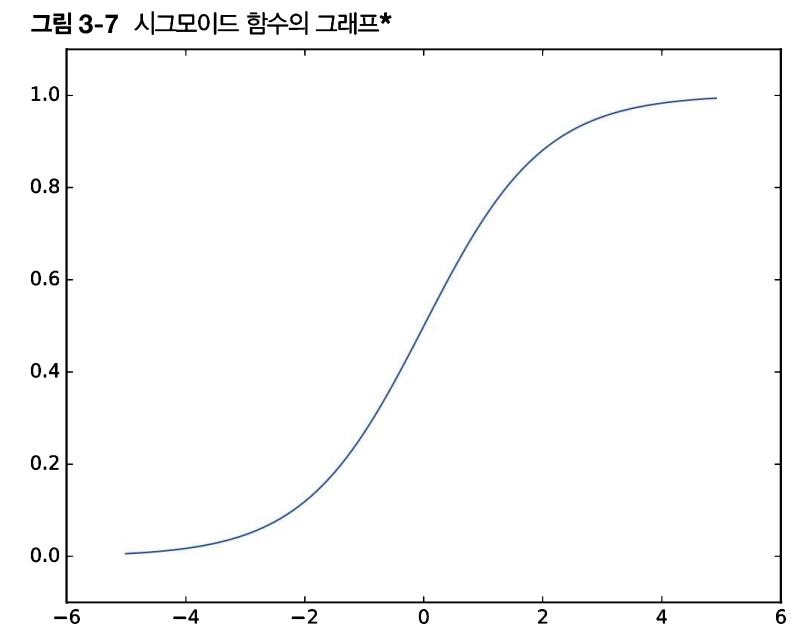
        - 입력 신호를 0과 1 사이의 **연속적인 값**으로 변환 -> 얼마나 확실한가?  
        - $f(x)=\frac{1}{1+e^{−x}}$
    - ReLU 함수 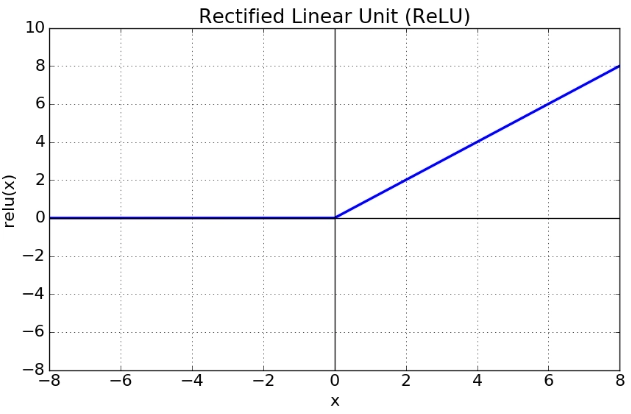  
        - 입력값 > 0 이면 그대로, <= 0 이면 0 출력
        - $f(x)=max(0,x)$
        - 딥러닝에서 가장 많이 사용: 계산이 간단하고 효율적, 은닉층에 비선형성 제공, 기울기 소실 문제 완화(시그모이드, Tanh는 문제 O)
    - Tanh 함수 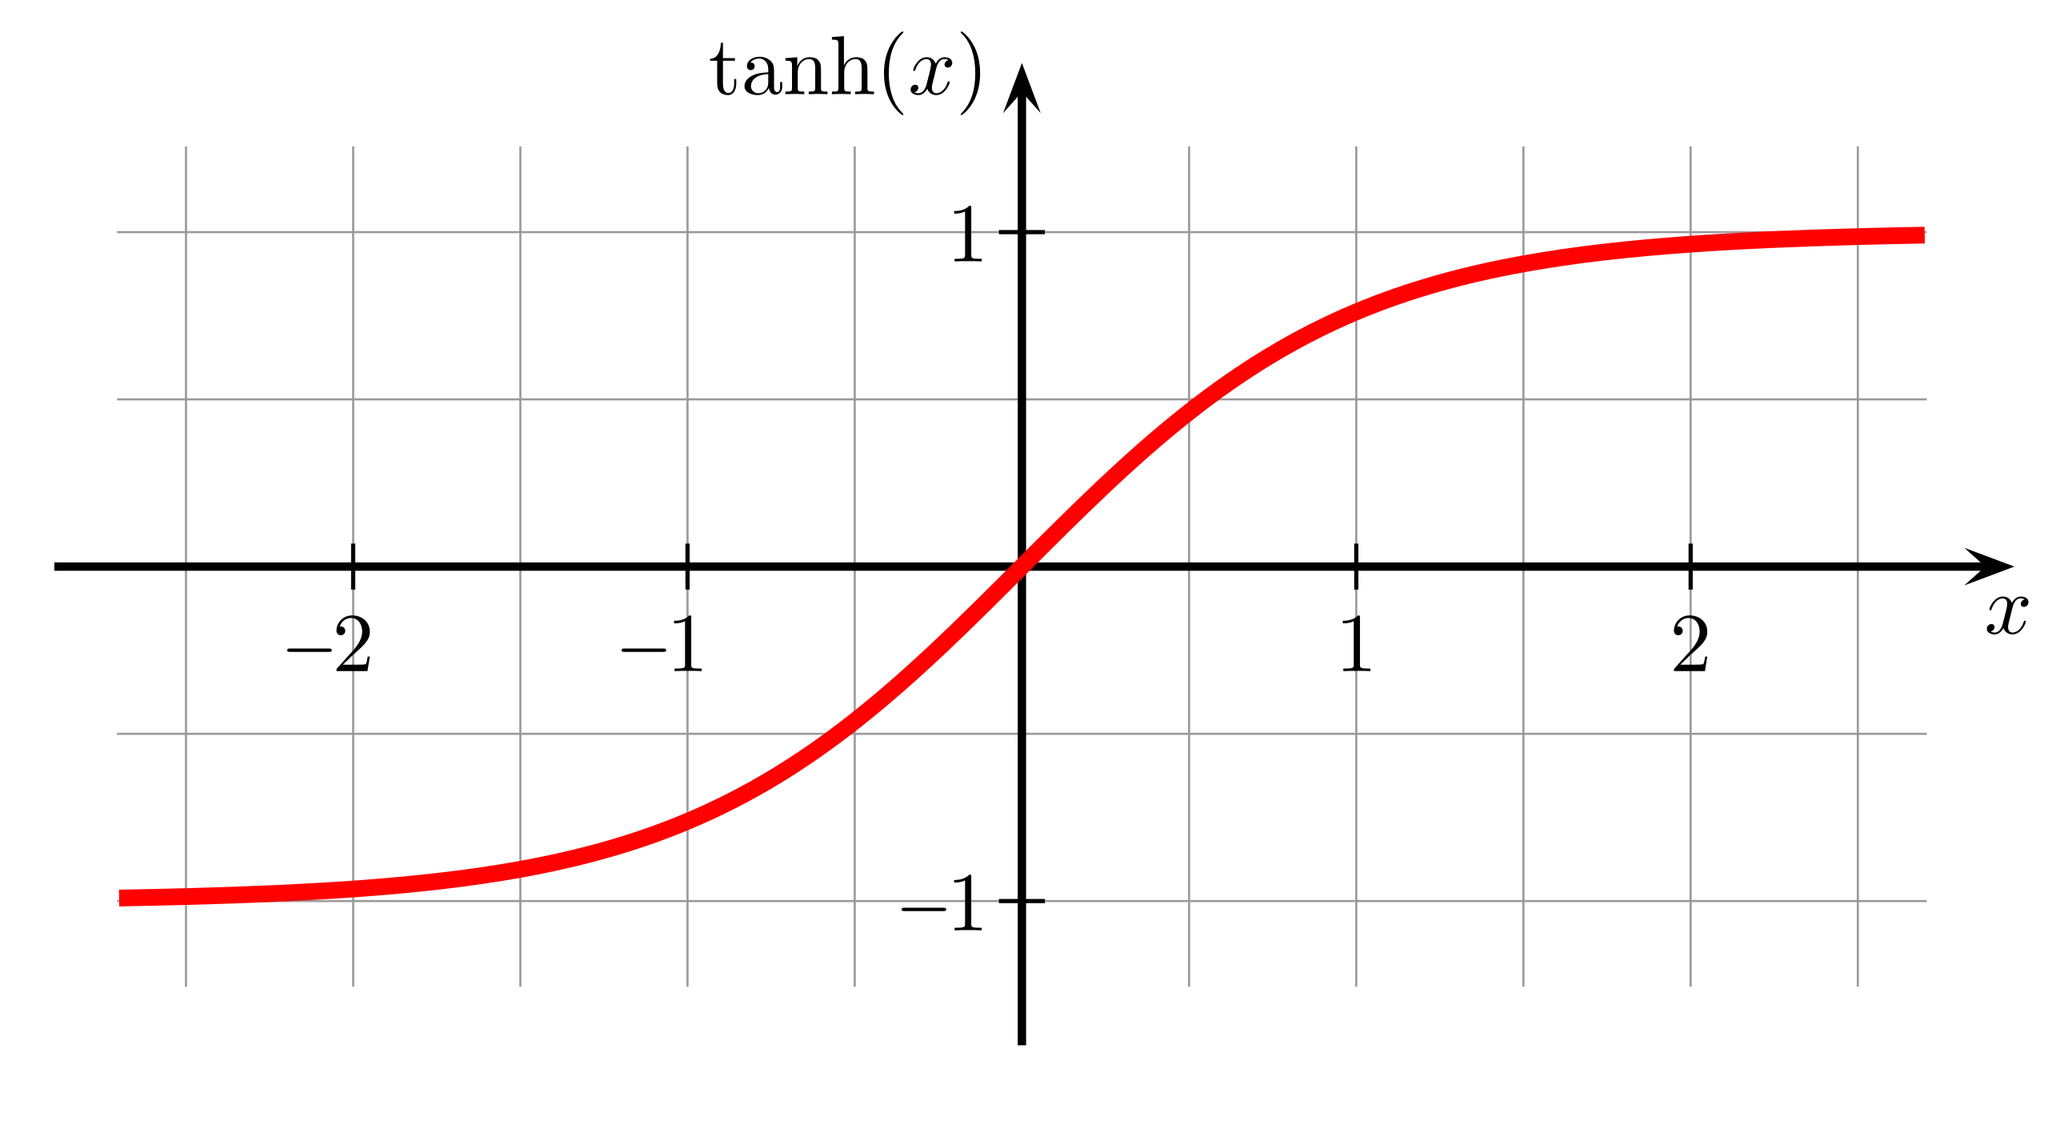  
        - -1 <= output <= 1 -> 출력값의 중심 = 0
        - $f(x)=tanh(x)=\frac{e^x-e^{−x}}{e^x+e^{−x}}$
        - 입력값의 중심을 0으로 맞추고 싶을 때 사용 -> 가중치 없데이트 안정적
    - 소프트맥스 함수 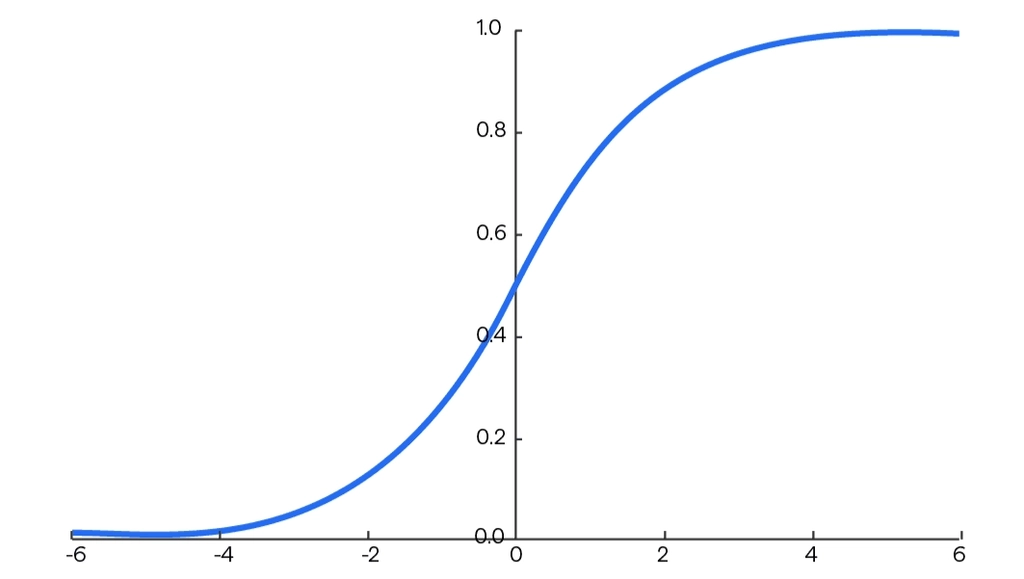  
        - 각 클래스에 대한 출력값을 확률로 변환
        - $f(x_i)=\frac{e^{x_i}}{∑_je^{x_j}}$
        - 다중 클래스 분류 문제의 출력층에서 사용 가능
        - 주로 크로스 엔트로피 손실함수와 함께 사용

## 경사하강법
### [기본 개념]
- 개념: 손실함수를 최소화하여 모델을 학습시키는 방법으로, 오차를 가장 작게 만드는 가중치와 편향을 찾는다.
- 배치(Batch): 학습 과정에서 가중치와 같은 매개변수를 조정하기 위해 사용하는 데이터의 묶음.  
    - 배치 크기가 너무 크면 -> 학습이 느려지고 메모리가 부족할 수 있다
    - 너무 작으면 -> 가중치가 자주 업데이트 -> 학습 불안정
- 에포크(Epoch): 모든 데이터셋을 학습하는 횟수
- 이터레이션(iteration)/스텝(step): 한 번의 에포크를 끝내기 위해 필요한 배치 수 -> 배치 크기 * 이터레이션 = 전체 데이터 크기
### [배치 경사하강법]
- 배치 경사하강법: 오차를 구할 때 **전체 데이터를 한 묶음으로 묶는** 가장 기본적인 경사하강법. (Batch size = Data size) 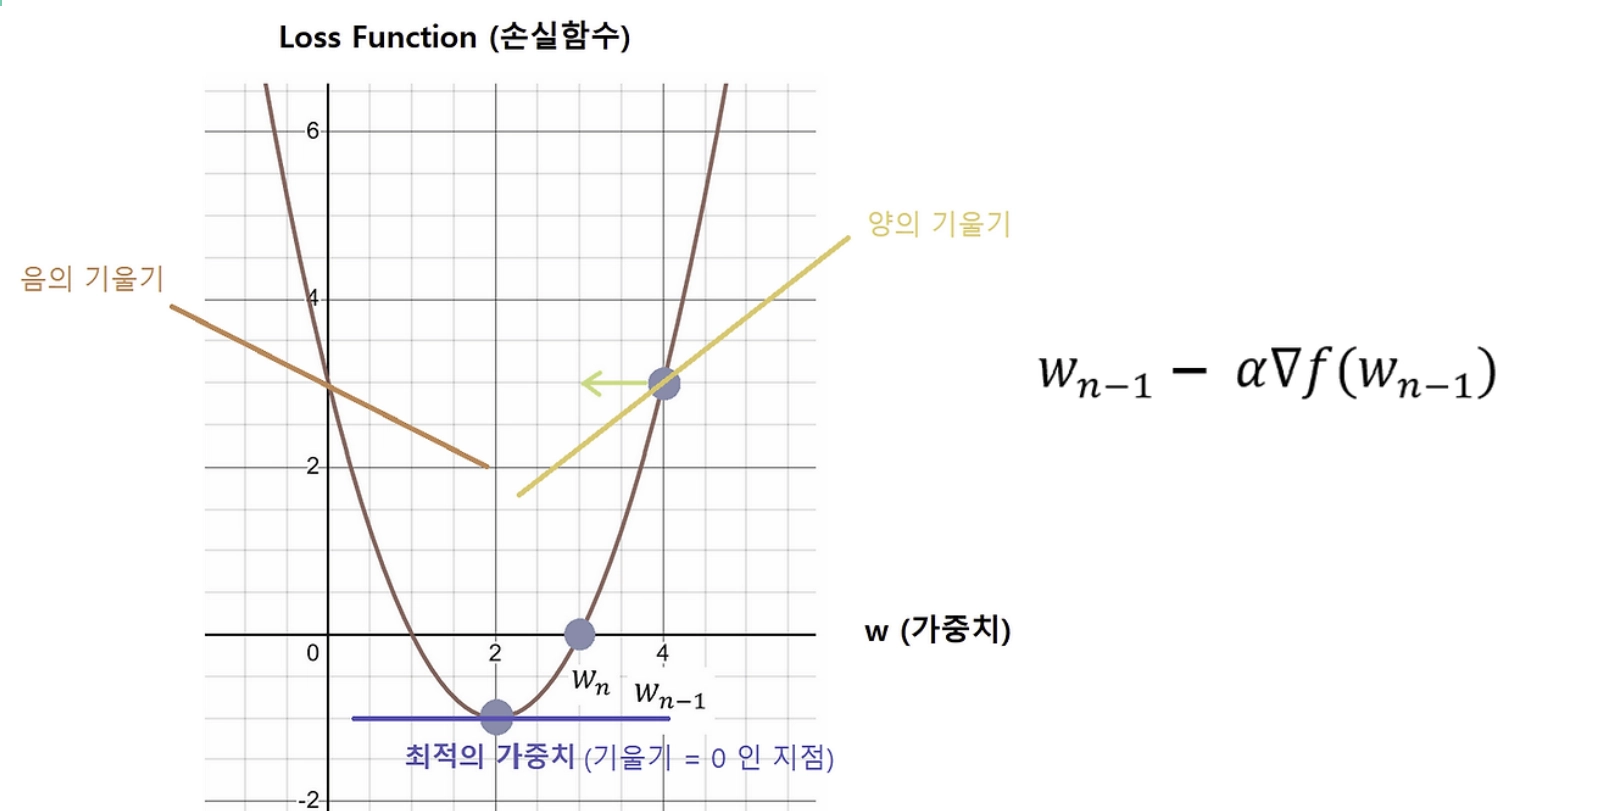  
    - 전체 데이터로 학습 -> 업데이트 횟수 적음
    - 메모리 많이 필요, 시간 오래 걸림
    - 안정적 수렴
- 배치 크기가 1인 확률적 경사하강법: **랜덤으로 선택된 하나의 데이터**에 대해서만 계산
    - 메모리 적게 소모, 빠른 계산
    - 매개변수의 변경폭 불안정
    - 정확도 낮음
- 미니 배치 경사하강법: 위의 두 경사하강법의 단점을 보완한 방법으로, **배치 크기를 적절히 지정($2^n$)**하여 매개변수의 값을 조정
    - 전체 데이터를 계산하는 것보다 빠름
    - 배치 크기가 1인 경사하강법보다 안정적

## 옵티마이저
- 경사하강법을 더 효율적이고 안정적으로 수행하기 위해 필요 -> 더 효과적인 최솟값을 찾을 수 있다.
- 모멘텀: 경사하강법 + **관성** -> 경사하강법에서 계산된 접선의 기울기에 **바로 한 시점 전의 접선의 기울기값을 일정 비율만큼 반영** 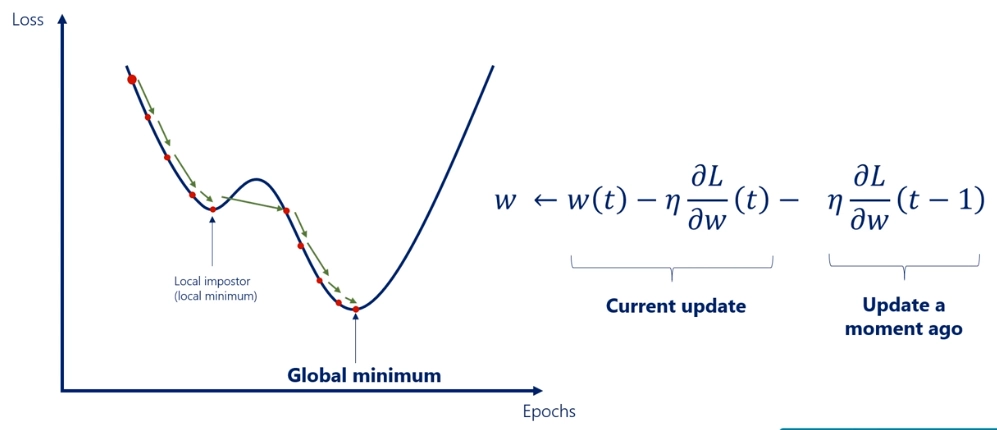
- 알엠에스프롭(RMSProp): 기울기가 큰 방향에서는 너무 많이, 작은 방향에서는 너무 작게 이동하는 기존 경사하강법의 문제를 해결 -> 각 학습률을 조정해서, **안정적**이고 빠르게 학습 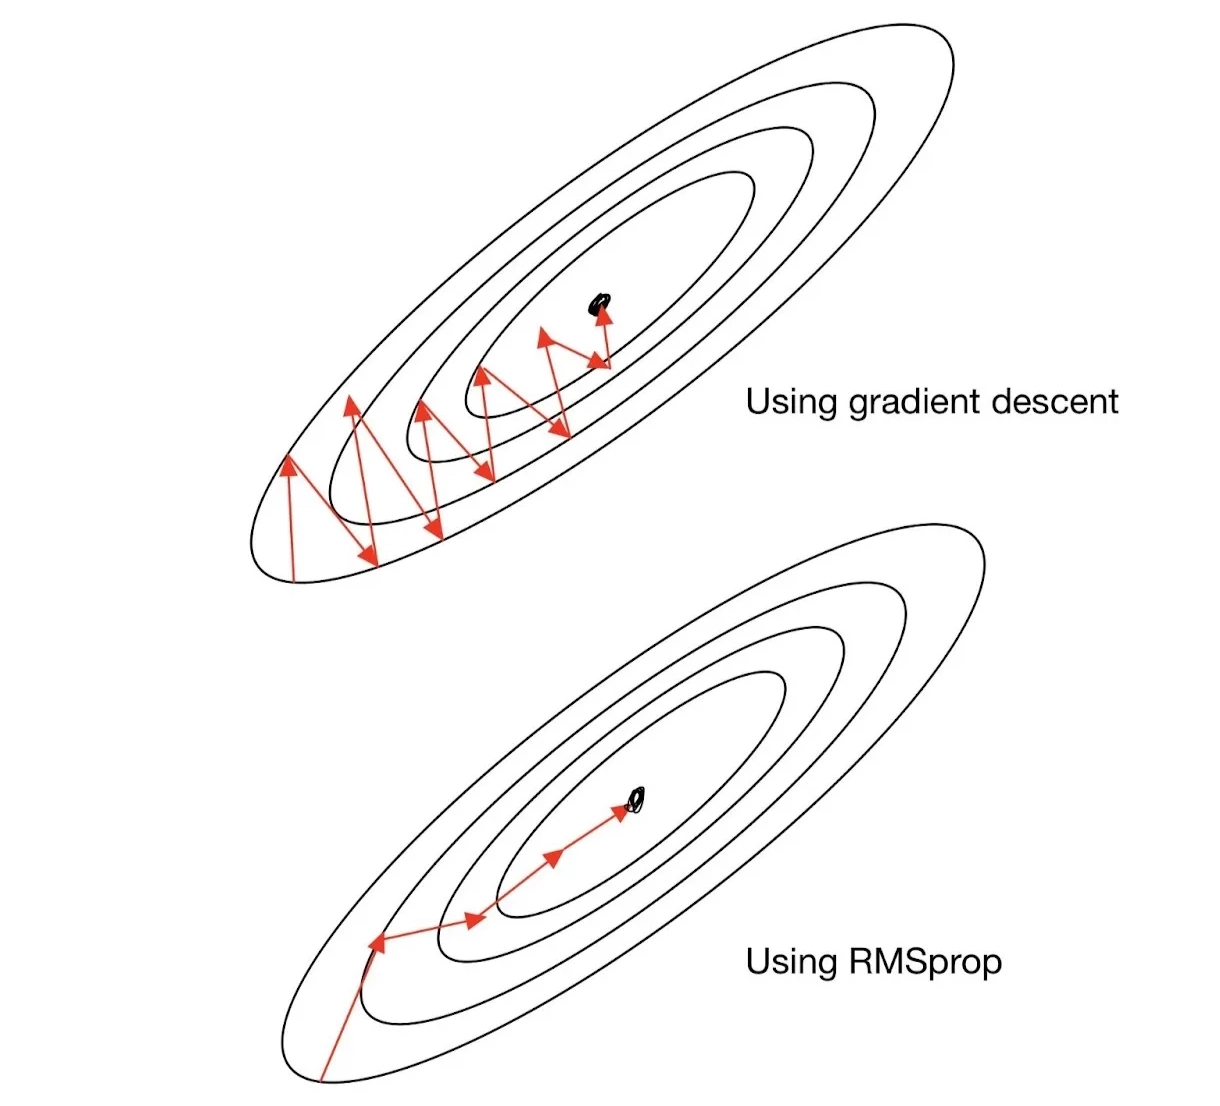
    - 급한 경사에서는 속도 낮춤
    - 완만한 경사에서는 속도 유지/증가
- 아담(Adam): 위의 두 방법을 합쳐 방향과 학습률 두 가지를 모두 확보. 각 파라미터의 1차 모멘트(기울기의 평균)와 2차 모멘트(기울기의 제곱 평균)을 사용하여 학습률을 조정

## 데이터 증강
- 개념: 기존 데이터에서 다양한 변형을 만들어 학습데이터를 늘리는 것
- 목적: 데이터 부족 문제 해결, 모델의 견고함(Robustness) 향상, 과적합 감소
- 주의: 변형된 데이터가 원본의 본질적인 특성을 잃지 않아야 하며, 태스크에 적절한 증강 방식을 선택
- 장점
    - 모델 성능 향상
    - 데이터 의존성 감소
    - 과적합 완화
    - 데이터 프라이버시 보호